In [1]:
import pandas as pd
df = pd.read_excel("D:\Customer_churn_project\Software_Churn_Dataset.xlsx")

In [2]:
df.head()

,CustomerID,Age,TenureMonths,ContractType,MonthlySpend,SupportTickets,HoursPerWeek,Churn
0,USER_10000,56,4,Annual,77.97,0,9.9,0
1,USER_10001,46,19,Monthly,51.75,3,12.1,0
2,USER_10002,32,11,Monthly,61.63,3,22.1,1
3,USER_10003,60,2,Annual,21.75,1,13.7,0
4,USER_10004,25,10,Annual,98.55,0,17.0,0


In [4]:
df.shape

(5000, 8)

In [5]:
df.info

<bound method DataFrame.info of       CustomerID  Age  TenureMonths ContractType  MonthlySpend  \
0     USER_10000   56             4       Annual         77.97   
1     USER_10001   46            19      Monthly         51.75   
2     USER_10002   32            11      Monthly         61.63   
3     USER_10003   60             2       Annual         21.75   
4     USER_10004   25            10       Annual         98.55   
...          ...  ...           ...          ...           ...   
4995  USER_14995   33            13       Annual         43.69   
4996  USER_14996   22            17       Annual         44.78   
4997  USER_14997   38            16       Annual         83.71   
4998  USER_14998   27             3      Monthly        106.54   
4999  USER_14999   36             2       Annual        116.83   

      SupportTickets  HoursPerWeek  Churn  
0                  0           9.9      0  
1                  3          12.1      0  
2                  3          22.1      1  

In [8]:
df.isnull().sum()

CustomerID          0
Age                 0
TenureMonths        0
ContractType        0
MonthlySpend        0
SupportTickets      0
HoursPerWeek      260
Churn               0
dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

C:\Users\shrey\AppData\Local\Temp\ipykernel_11360\1143975376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='pastel')


Text(0, 0.5, 'Number of Users')

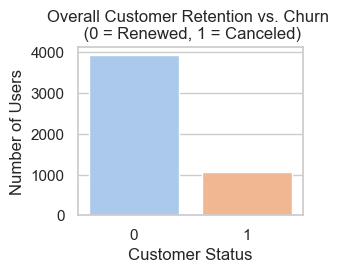

In [12]:
# Chart 1: (Churn)
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Churn', palette='pastel')
plt.title('Overall Customer Retention vs. Churn \n (0 = Renewed, 1 = Canceled)')
plt.xlabel('Customer Status')
plt.ylabel('Number of Users')

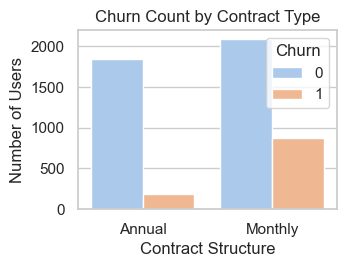

In [19]:
# Chart 2: Churn segmented by Contract Type
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='ContractType', hue='Churn', palette='pastel')
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Structure')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_11360\863094645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='SupportTickets', palette='pastel')


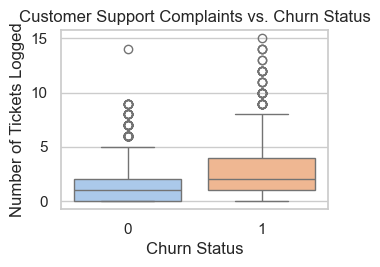

In [18]:
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Churn', y='SupportTickets', palette='pastel')
plt.title('Customer Support Complaints vs. Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Number of Tickets Logged')
plt.tight_layout()
plt.show()

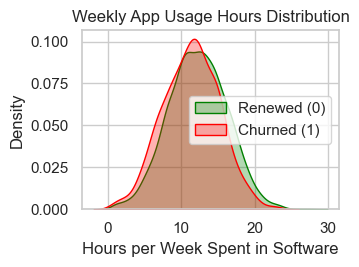

In [17]:
plt.subplot(2, 2, 4)
sns.kdeplot(data=df[df['Churn'] == 0]['HoursPerWeek'], label='Renewed (0)', fill=True, color='green', alpha=0.3)
sns.kdeplot(data=df[df['Churn'] == 1]['HoursPerWeek'], label='Churned (1)', fill=True, color='red', alpha=0.3)
plt.title('Weekly App Usage Hours Distribution')
plt.xlabel('Hours per Week Spent in Software')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Data Preprocessing

In [20]:
median_hours = df['HoursPerWeek'].median()
df['HoursPerWeek'] = df['HoursPerWeek'].fillna(median_hours)

In [21]:
df['ContractType'] = df['ContractType'].map({'Monthly': 1, 'Annual': 0})

In [22]:
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

In [25]:
print("\n--- MISSING VALUES CHECK ---")
print(X.isnull().sum())


--- MISSING VALUES CHECK ---
Age               0
TenureMonths      0
ContractType      0
MonthlySpend      0
SupportTickets    0
HoursPerWeek      0
dtype: int64


In [24]:
print("--- PREPROCESSED FEATURES (X) ---")
print(X.head())

--- PREPROCESSED FEATURES (X) ---
   Age  TenureMonths  ContractType  MonthlySpend  SupportTickets  HoursPerWeek
0   56             4             0         77.97               0           9.9
1   46            19             1         51.75               3          12.1
2   32            11             1         61.63               3          22.1
3   60             2             0         21.75               1          13.7
4   25            10             0         98.55               0          17.0


In [ ]:
# Data Splitting

In [26]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"(X_train): {X_train.shape[0]} rows")
print(f"(X_test):  {X_test.shape[0]} rows")
print(f"Number of features per row: {X_train.shape[1]}")

(X_train): 4000 rows
(X_test):  1000 rows
Number of features per row: 6


In [32]:
# Model Training

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [35]:
rf_model.fit(X_train, y_train)
print("MODEL TRAINING COMPLETE")

MODEL TRAINING COMPLETE


In [36]:
# Test and Evaluation

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

In [38]:
y_pred = rf_model.predict(X_test)

In [39]:
print("MODEL PERFORMANCE REPORT")
print(classification_report(y_test, y_pred))

MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       786
           1       0.57      0.30      0.39       214

    accuracy                           0.80      1000
   macro avg       0.70      0.62      0.64      1000
weighted avg       0.77      0.80      0.78      1000



In [41]:
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives  (Predicted Stayed, Actually Stayed):  {cm[0][0]}")
print(f"False Positives (Predicted Churned, Actually Stayed): {cm[0][1]}")
print(f"False Negatives (Predicted Stayed, Actually Churned): {cm[1][0]}")
print(f"True Positives  (Predicted Churned, Actually Churned): {cm[1][1]}")

True Negatives  (Predicted Stayed, Actually Stayed):  737
False Positives (Predicted Churned, Actually Stayed): 49
False Negatives (Predicted Stayed, Actually Churned): 150
True Positives  (Predicted Churned, Actually Churned): 64


In [42]:
# Live Prediction Function

In [44]:
def predict_customer_churn(age, tenure, contract, spend, tickets, hours):
    
    contract_numeric = 1 if contract == 'Monthly' else 0
    customer_data = [[age, tenure, contract_numeric, spend, tickets, hours]]
    
    prediction = rf_model.predict(customer_data)[0]
    probability = rf_model.predict_proba(customer_data)[0][1]
    
    print("=============================================")
    print("       LIVE CUSTOMER RISK ASSESSMENT         ")
    print("=============================================")
    print(f"Customer Profile: {age}yo | {contract} Plan | {tenure} Months Tenure")
    print(f"Usage Metrics:    {hours} hrs/week | {tickets} Open Support Tickets")
    print("---------------------------------------------")
    
    if prediction == 1:
        print(f"⚠️ ALERT: High Risk of Churn!")
    else:
        print(f"✅ STATUS: Loyal Customer (Low Risk)")
        
    print(f"📊 Churn Probability Score: {probability * 100:.1f}%")
    print("=============================================\n")

# Scenario A:
predict_customer_churn(age=28, tenure=2, contract='Monthly', spend=89.99, tickets=4, hours=3.5)

# Scenario B: 
predict_customer_churn(age=42, tenure=18, contract='Annual', spend=45.00, tickets=0, hours=24.0)

       LIVE CUSTOMER RISK ASSESSMENT         
Customer Profile: 28yo | Monthly Plan | 2 Months Tenure
Usage Metrics:    3.5 hrs/week | 4 Open Support Tickets
---------------------------------------------
⚠️ ALERT: High Risk of Churn!
📊 Churn Probability Score: 75.0%

       LIVE CUSTOMER RISK ASSESSMENT         
Customer Profile: 42yo | Annual Plan | 18 Months Tenure
Usage Metrics:    24.0 hrs/week | 0 Open Support Tickets
---------------------------------------------
✅ STATUS: Loyal Customer (Low Risk)
📊 Churn Probability Score: 2.0%



C:\Users\shrey\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\shrey\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\shrey\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\shrey\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
